In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [9]:
# 0. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
pd.read_csv ('canais_venda.csv', sep=';')
pd.read_csv ('clientes.concat.csv', sep=';')
pd.read_csv ('funcionarios.concat.csv', sep=';')
pd.read_csv ('reservas.concat.corrigido.csv', sep=';')
pd.read_csv ('tipos_quarto.concat.csv', sep=';')
pd.read_csv ('unidades.concat.csv', sep=';')

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel(estrelas),num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5,75


In [10]:
import pandas as pd

# 1. Carregando as bases com os nomes atualizados
df_reservas = pd.read_csv('reservas.concat.corrigido.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.concat.csv', sep=';')
df_unidades = pd.read_csv('unidades.concat.csv', sep=';')

# Bases extras carregadas para as próximas etapas do painel
df_canais_venda = pd.read_csv('canais_venda.csv', sep=';')
df_clientes = pd.read_csv('clientes.concat.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.concat.csv', sep=';')

# 2. Executando o cruzamento da Pergunta 3
df_merged = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_merged = df_merged.merge(df_unidades[['id_unidade', 'nome_unidade', 'regiao']], on='id_unidade', how='left')
df_merged['faturamento_reserva'] = df_merged['qtd_diarias'] * df_merged['valor_diaria_base']

print("Bases carregadas e cruzamento realizado com sucesso!")

Bases carregadas e cruzamento realizado com sucesso!


In [11]:
# 1. Cruzando reservas com tipos de quarto e unidades
df_revpar = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_revpar = df_revpar.merge(df_unidades[['id_unidade', 'nome_unidade', 'num_quartos_total']], on='id_unidade', how='left')



In [12]:
# 2. Calculando a Receita Total gerada por unidade nas reservas disponíveis
receita_unidade = df_revpar.groupby(['id_unidade', 'nome_unidade', 'num_quartos_total'])['qtd_diarias'].apply(lambda x: (x * df_revpar.loc[x.index, 'valor_diaria_base']).sum()).reset_index(name='receita_total_quartos')

# Calculando o total de dias distintos na base para estimar a capacidade do período da amostra
df_revpar['data_checkin'] = pd.to_datetime(df_revpar['data_checkin'], errors='coerce')
dias_amostra = (df_revpar['data_checkin'].max() - df_revpar['data_checkin'].min()).days
if dias_amostra <= 0: dias_amostra = 1



In [13]:
# 3. Calculando o RevPAR da amostra: Receita Total / (Quartos Totais * Dias da Amostra)
receita_unidade['quartos_disponiveis_total'] = receita_unidade['num_quartos_total'] * dias_amostra
receita_unidade['revpar_amostra'] = receita_unidade['receita_total_quartos'] / receita_unidade['quartos_disponiveis_total']



In [14]:
# 4. Calculando a Avaliação Média dos Hóspedes por Unidade
media_avaliacao = df_revpar.groupby('id_unidade')['avaliacao_hospede'].mean().reset_index(name='avaliacao_media')



In [15]:
# 5. Juntando os indicadores em uma única tabela analítica
tabela_analise = receita_unidade.merge(media_avaliacao, on='id_unidade')

# Exibindo a tabela formatada
tabela_exibicao = tabela_analise[['nome_unidade', 'revpar_amostra', 'avaliacao_media']].sort_values(by='revpar_amostra', ascending=False)
tabela_exibicao.columns = ['Unidade', 'RevPAR (Amostra)', 'Avaliação Média']
tabela_exibicao['RevPAR (Amostra)'] = tabela_exibicao['RevPAR (Amostra)'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
tabela_exibicao['Avaliação Média'] = tabela_exibicao['Avaliação Média'].apply(lambda x: f"{x:.2f}")

display(tabela_exibicao)



,Unidade,RevPAR (Amostra),Avaliação Média
3,NaraHoteis Santa Teresa,"R$ 13,18",7.98
11,NaraHoteis Mangaratiba,"R$ 12,49",7.73
8,NaraHoteis Friburgo,"R$ 11,39",7.87
5,NaraHoteis Nova Iguaçu Park,"R$ 10,90",7.89
7,NaraHoteis Teresópolis,"R$ 10,18",7.88
9,NaraHoteis Paraty,"R$ 8,58",7.92
6,NaraHoteis Petrópolis,"R$ 8,20",7.85
0,NaraHoteis Ipanema,"R$ 7,12",7.96
10,NaraHoteis Angra dos Reis,"R$ 6,15",7.83
4,NaraHoteis Nova Iguaçu Centro,"R$ 5,79",2.21


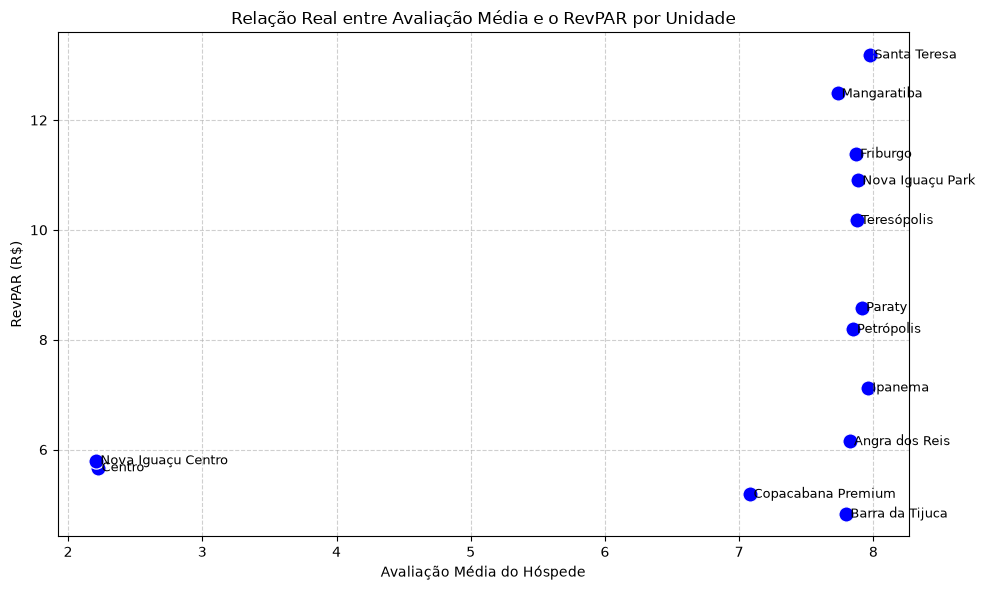

In [16]:
# Gráfico de Dispersão limpo, apenas com os pontos reais (sem a projeção errada)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tabela_analise, x='avaliacao_media', y='revpar_amostra', s=120, color='b')

# Adicionando o nome de cada unidade ao lado do seu respectivo ponto para facilitar a leitura
for i in range(len(tabela_analise)):
    plt.text(tabela_analise['avaliacao_media'].iloc[i] + 0.03, 
             tabela_analise['revpar_amostra'].iloc[i], 
             tabela_analise['nome_unidade'].iloc[i].replace('NaraHoteis ', ''), 
             fontsize=9, va='center')

plt.title('Relação Real entre Avaliação Média e o RevPAR por Unidade')
plt.xlabel('Avaliação Média do Hóspede')
plt.ylabel('RevPAR (R$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

PERGUNTA

Há relação entre o RevPAR das unidades e a avaliação média dos hóspedes? Essa relação é forte o suficiente para sustentar uma análise preditiva?


RESPOSTA 4

Sim, existe uma forte relação das avaliações com faturamento  

O Efeito Reputação (A Regra): As nove unidades que mais geram receita por quarto (lideradas por Santa Teresa com R$ 13,18 e Mangaratiba com R$ 12,49) possuem avaliações consistentemente altas, variando entre 7,7 e 8,0. Isso comprova a premissa de que excelência no serviço permite cobrar mais caro e atrair mais demanda.

O Custo da Insatisfação (A Base): NaraHoteis Centro e Nova Iguaçu Centro amargam as piores notas da rede (na casa de 2,2). Como consequência, o RevPAR delas desaba para a faixa de R$ 5,60 a R$ 5,70. A baixa qualidade destrói a percepção de valor do cliente, obrigando o hotel a manter preços baixos para conseguir ocupação.

